# Ordering GUNW-S1 products from ASF on-demand using ariaOrderASF.py

**Author**: David Bekaert - Flemish Institute for Technological Research

This notebook demonstrates how to use the **`ariaOrderASF.py`** command line tool to discover ARIA Sentinel-1 GUNW frames, generate interferogram pair lists, and order products from ASF via HyP3 on-demand processing. The tool provides an end-to-end workflow from identifying relevant frames over an area of interest to submitting processing orders and tracking job status.

In this notebook, we will walk through the full ordering workflow using an example over **Belgium** (Brussels area), covering ascending track data.

<div class="alert alert-warning">
<b>Note:</b> 
This tool supports Sentinel-1 GUNW only, not NISAR.
</div>

<div class="alert alert-warning">
<b>ASF / Earthdata credentials required:</b> 
Ordering products requires a NASA Earthdata URS user login. You will need to authenticate with ASF to submit jobs via HyP3. Make sure you have an active account at <a href="https://urs.earthdata.nasa.gov/">https://urs.earthdata.nasa.gov/</a>.

Save your credentials to a <code>.netrc</code> file in your <code>$HOME</code> directory.
</div>

## Table of Contents

- [Overview of ariaOrderASF.py](#overview)
- [Step 1: Discover ARIA frames (--getframes)](#step1)
- [Step 2: Generate interferogram pairs (--getpairs)](#step2)
- [Step 3: Order pairs (--orderpairs)](#step3)
- [Step 4: Check job status (--statusjobs)](#step4)

## Prep: Credentials setup

If you do not already have a `.netrc` file configured with your Earthdata credentials, run the cell below to create one.

In [ ]:
import os

# create .netrc if it does not exist    
if not os.path.exists(os.path.expanduser('~/.netrc')):
    print('NEEDED for ASF ordering: \n Link to create account : https://urs.earthdata.nasa.gov/')
    earthdata_user = input('Please type your Earthdata username:')
    earthdata_user = str(earthdata_user)
    earthdata_password = input('Please type your Earthdata password:')
    earthdata_password = str(earthdata_password)
    os.system('echo machine urs.earthdata.nasa.gov login "{usern}" password "{passwd}" > ~/.netrc; chmod 600 ~/.netrc'.format( \
              usern = earthdata_user, passwd = earthdata_password))

In [17]:
import os
os.environ['PATH'] = os.path.dirname(os.sys.executable) + os.pathsep + os.environ.get('PATH', '')

<a id='overview'></a>

## Overview of ariaOrderASF.py

The **`ariaOrderASF.py`** program provides a command-line interface to:
1. **Discover ARIA frames** covering a bounding box (`--getframes`)
2. **Generate interferogram pair lists** for a given frame (`--getpairs`)
3. **Submit pairs to HyP3** for on-demand processing (`--orderpairs`)
4. **Check the status** of previously submitted jobs (`--statusjobs`)

Running **`ariaOrderASF.py`** with **`-h`** will show all available options:

In [4]:
!ariaOrderASF.py -h

usage: ariaOrderASF.py [-h] (--getframes | --getpairs | --orderpairs |
                       --statusjobs) [-b BBOX] [-t TRACK]
                       [-d {ascending,descending,a,d,A,D,ASCENDING,DESCENDING}]
                       [--frame FRAME]
                       [--network {sequential,seasonal,annual}]
                       [--num-neighbors NUM_NEIGHBORS]
                       [--seasonal-window SEASONAL_WINDOW] [-s START] [-e END]
                       [--pairs-file PAIRS_FILE] [--job-name JOB_NAME]
                       [--dry-run] [--limit LIMIT] [--status-name STATUS_NAME]
                       [--job-ids JOB_IDS] [-w WD] [-v]
                       [--log-level {debug,info,warning,error}]

Command line interface to identify ARIA Sentinel-1 GUNW frames, generate interferogram pair lists, and order products from ASF via HyP3.

NOTE: This tool supports Sentinel-1 GUNW only, not NISAR.

options:
  -h, --help            show this help message and exit
  --getframes        

The workflow consists of four main modes, each building on the previous step:

| Mode | Flag | Description |
|------|------|-------------|
| Frame Discovery | `--getframes` | Identify which ARIA frames intersect your area of interest |
| Pair Generation | `--getpairs` | Generate interferogram pairs for a specific frame, checking what already exists at ASF |
| Ordering | `--orderpairs` | Submit new pairs to HyP3 for processing (with dry-run and limit options) |
| Job Status | `--statusjobs` | Check the status of previously submitted HyP3 jobs |

<a id='step1'></a>

## Step 1: Discover ARIA frames (`--getframes`)

The first step is to find which ARIA frames cover your area of interest. You specify a bounding box in **SNWE** format (South North West East) using the **`-b`** option.

For our Belgium example, we define a bounding box around the Brussels area. We also filter for **ascending** passes only using **`-d a`**.

The command will:
- Query ASF for ARIA frames intersecting the bounding box
- Print a summary of discovered frames (track, frame ID, direction)
- Generate an overview map showing the frame footprints

In [5]:
!ariaOrderASF.py --getframes -b '50.5755 50.9642 4.392 4.8552' -d a

2026-03-30 15:01:41,335 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:01:41,336 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:01:41,336 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:01:41,336 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:01:41,336 - ariaOrderASF.py - INFO - Bounding box: S=50.5755  N=50.9642  W=4.3920  E=4.8552
2026-03-30 15:01:41,336 - ariaOrderASF.py - INFO - Querying frames via asf_enumeration ...
2026-03-30 15:01:41,393 - ariaOrderASF.py - INFO - Found 4 frames.

MATCHING ARIA SENTINEL-1 GUNW FRAMES
Found 4 frames matching criteria:

Frame ID     Track    Direction    Bounds (W, S, E, N)
----------------------------------------------------------------------
13612        88       ASCENDING    (4.31, 48.90, 8.28, 50.70)
13613        88       ASCENDIN

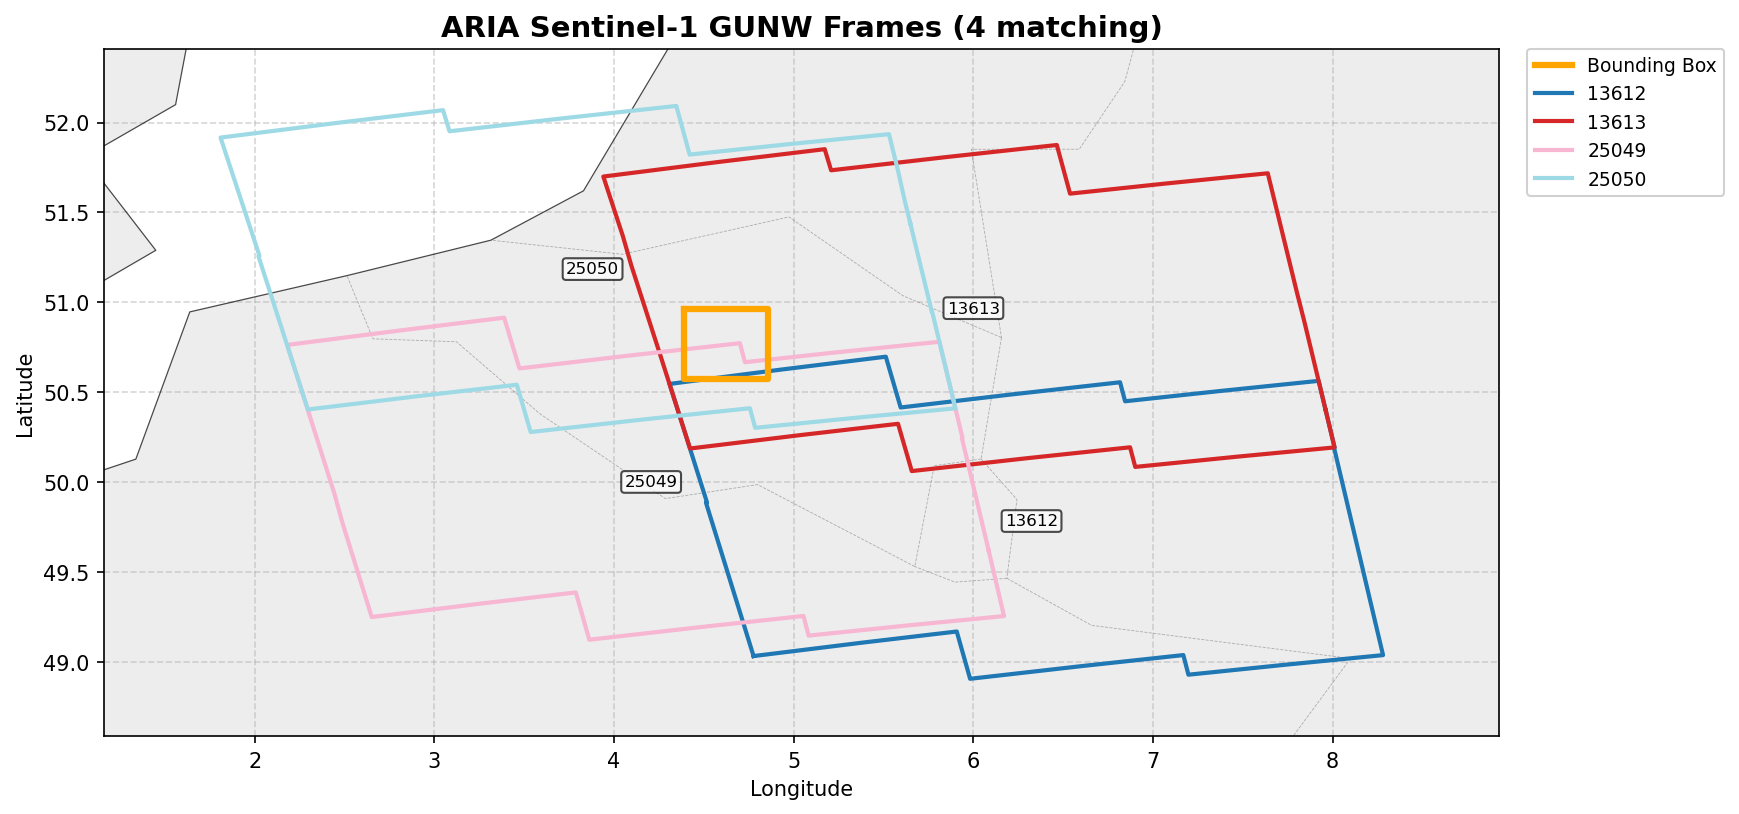

In [22]:
from IPython.display import Image, display
display(Image(filename='support_docs/aria_frames_map.png'))

The output lists all ascending frames that intersect the Brussels bounding box. Each row shows the track number, frame ID, and flight direction. The map provides a visual overview of the frame footprints relative to the bounding box.

You can optionally narrow the search further by specifying a **track number** with **`-t`**:

In [6]:
!ariaOrderASF.py --getframes -b '50.5755 50.9642 4.392 4.8552' -d a -t 088

2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - Bounding box: S=50.5755  N=50.9642  W=4.3920  E=4.8552
2026-03-30 15:01:53,065 - ariaOrderASF.py - INFO - Querying frames via asf_enumeration ...
2026-03-30 15:01:53,070 - ariaOrderASF.py - INFO - Found 2 frames.

MATCHING ARIA SENTINEL-1 GUNW FRAMES
Found 2 frames matching criteria:

Frame ID     Track    Direction    Bounds (W, S, E, N)
----------------------------------------------------------------------
13612        88       ASCENDING    (4.31, 48.90, 8.28, 50.70)
13613        88       ASCENDIN

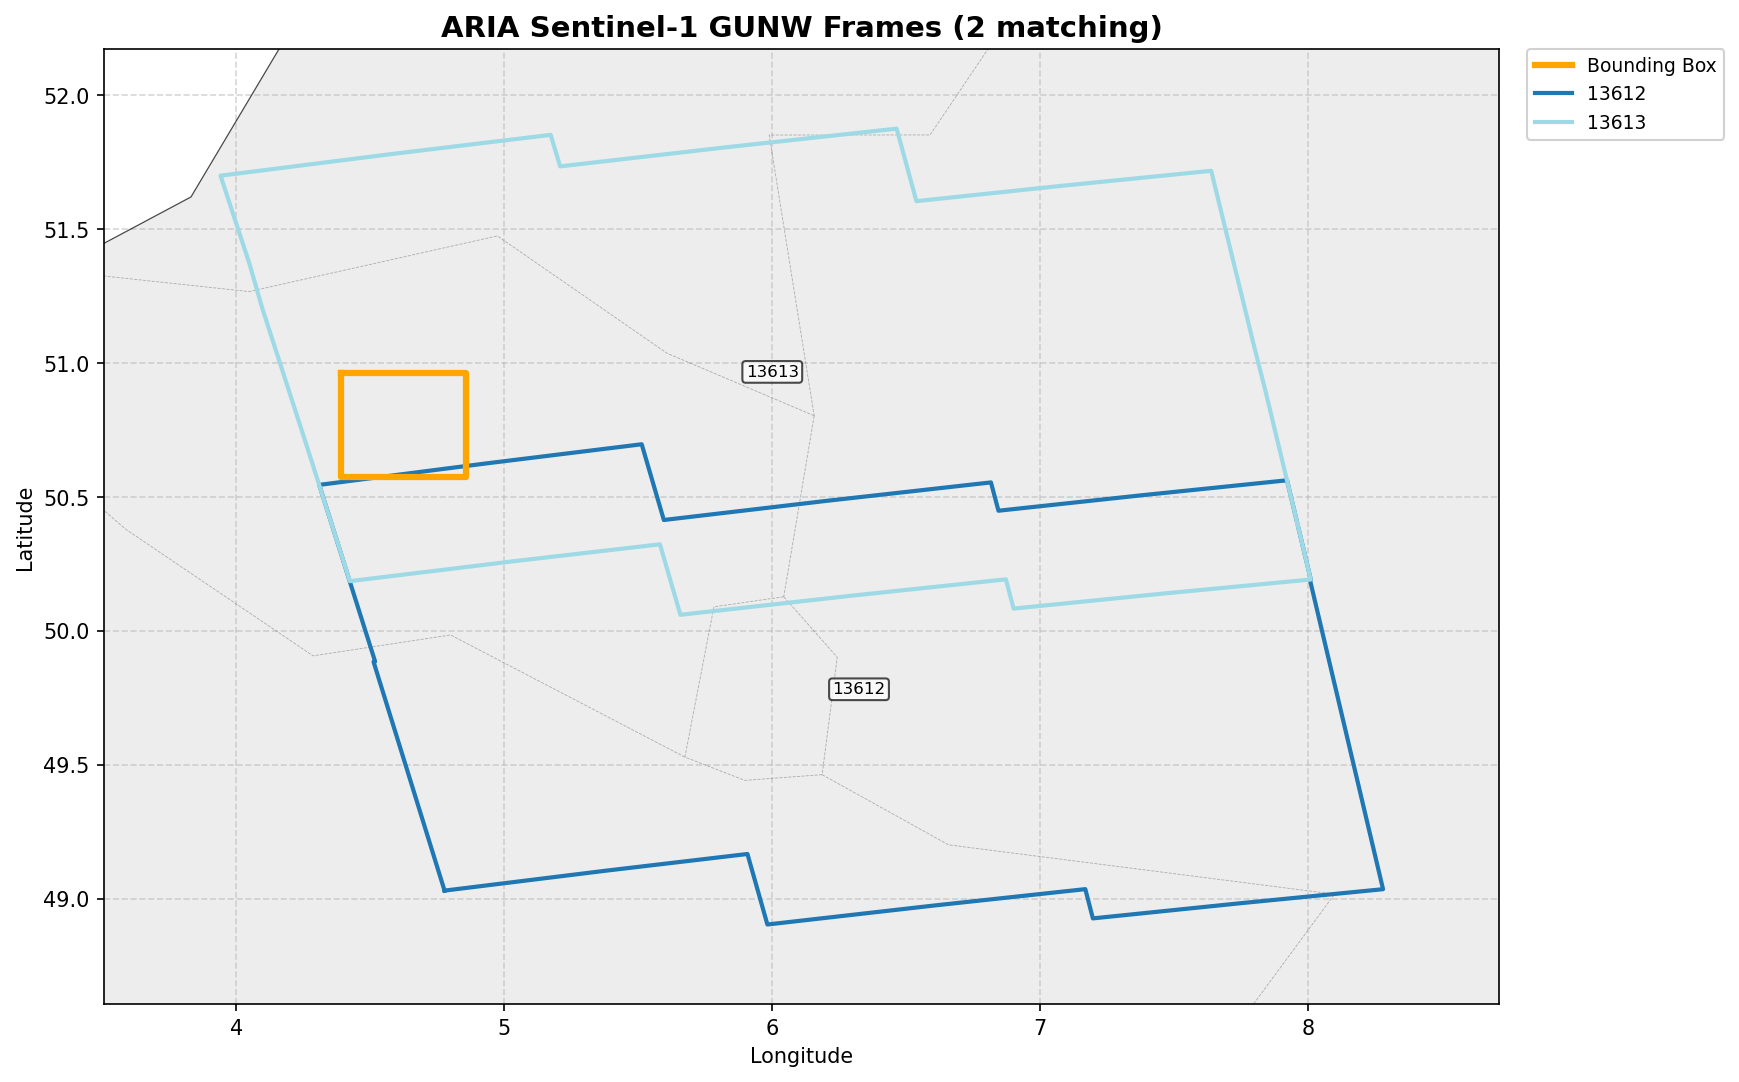

In [23]:
from IPython.display import Image, display
display(Image(filename='support_docs/aria_frames_map_1.png'))

<div class="alert alert-info">
<b>Tip:</b> 
If you omit the <code>-d</code> flag, both ascending and descending frames will be returned. You can also pass a comma-separated list of tracks with <code>-t</code> (e.g., <code>-t 088,037</code>).
</div>

<a id='step2'></a>

## Step 2: Generate interferogram pairs (`--getpairs`)

Once you have identified the frame of interest, you can generate an interferogram pair list using **`--getpairs`**. You must specify the **`--frame`** ID obtained from Step 1.

The tool supports different network types, including:
- **`sequential`** (default): Nearest N temporal neighbors. Good for continuous deformation monitoring.
- **`annual`**: Nearest neighbor ~1 year apart. Useful for long-term deformation rates.

The **`--num-neighbors`** option controls how many nearest neighbors to use (default: 1). Using `--num-neighbors 2` allows redundancy to ensure no temporal gaps in subsequent time-series analysis.

### Sequential nearest-2-neighbor pairs

Here we generate a sequential nearest-2-neighbor network for frame **25050** (ascending over Belgium):

In [18]:
!ariaOrderASF.py --getpairs --network sequential --num-neighbors 2 --frame 25050

2026-03-30 15:15:42,309 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:15:42,309 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:15:42,309 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:15:42,309 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:15:42,310 - ariaOrderASF.py - INFO - Frame 25050 | 2014-01-01 → 2026-03-30
2026-03-30 15:15:42,310 - ariaOrderASF.py - INFO - Querying acquisitions for frame 25050 via asf_enumeration ...
2026-03-30 15:15:42,312 - root - INFO - 'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 25 simplified to 24 with proximity threshold of 0.0004'
2026-03-30 15:15:42,312 - root - INFO - 'type': 'REVERSE': 'report': Reversed polygon winding order
2026-03-30 15:15:45,356 - ariaOrderASF.py - INFO - Found 502 acquisitions in 2014-01

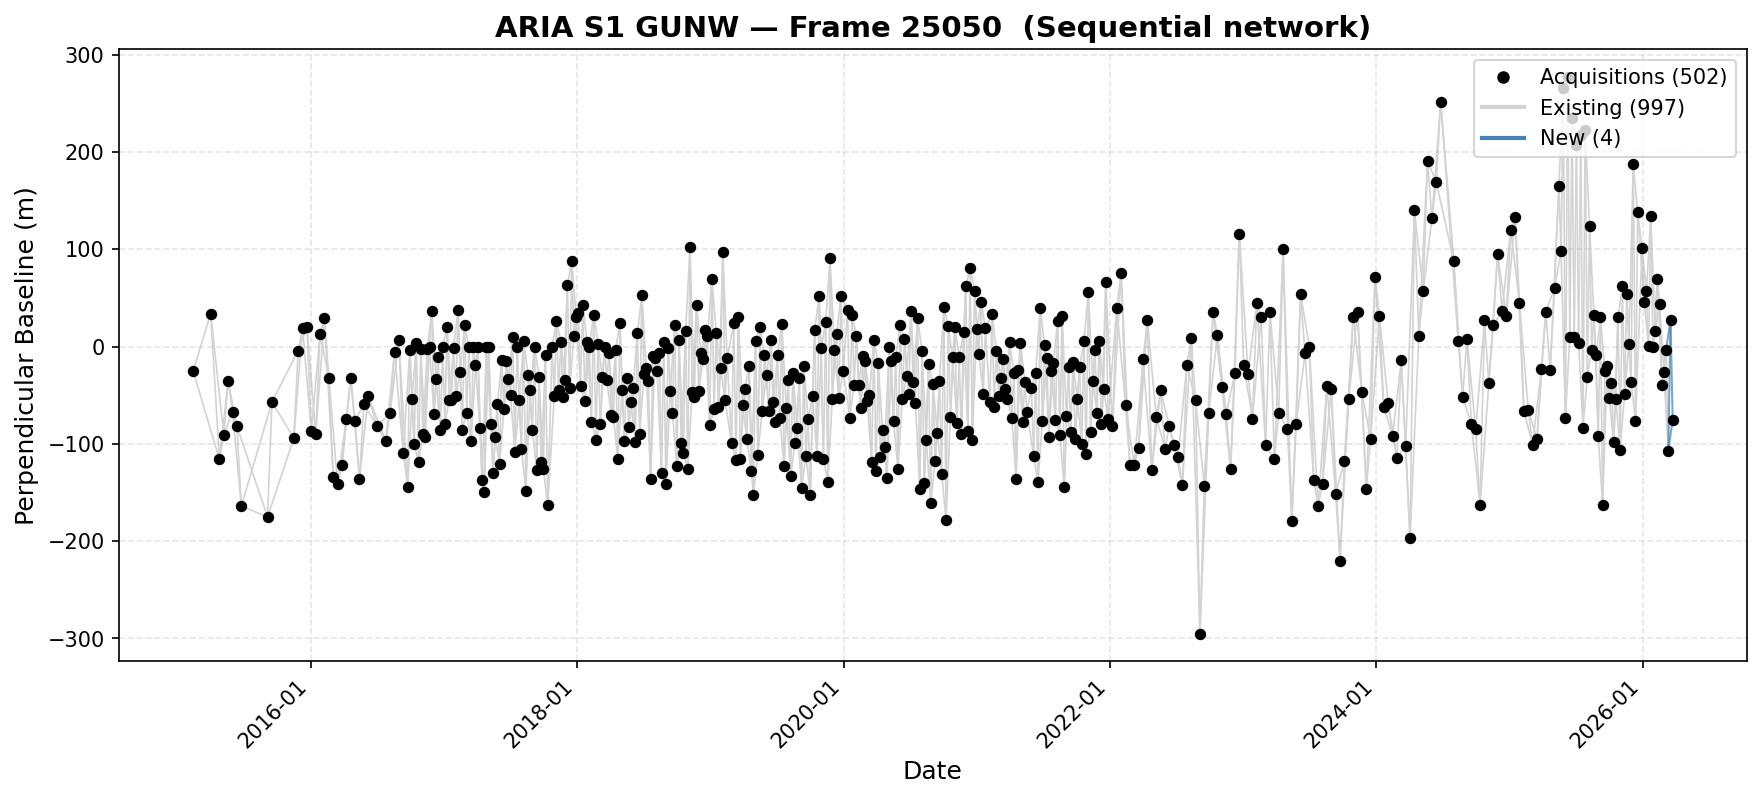

In [24]:
from IPython.display import Image, display
display(Image(filename='support_docs/aria_baseline_frame25050.png'))

The tool will:
1. Query ASF for all acquisitions available for the specified frame
2. Compute perpendicular baselines
3. Generate the requested pair network
4. **Check the ASF archive** to identify which pairs already exist as GUNW products
5. Output a summary showing existing vs. new pairs, credit cost estimates, and your remaining monthly quota
6. Save a pairs CSV file and a baseline plot

The **baseline plot** shows existing pairs (typically in one color) and new pairs that need to be ordered (in another color), giving a visual overview of the temporal and perpendicular baseline coverage.

The **pairs CSV file** (e.g., `aria_pairs_frame25050.csv`) contains all pair information and can be edited before ordering — you can remove unwanted pairs by deleting rows from the CSV.

<div class="alert alert-info">
<b>Credit cost:</b> 
The summary output includes the estimated credit cost for ordering all new pairs (each pair costs 60 credits), your ASF monthly quota (typically 8,000 credits), and whether the order fits within your remaining credits. If the cost exceeds your remaining credits, consider using <code>--limit</code> with <code>--orderpairs</code> to submit in smaller batches.
</div>

### Other network types

You can also generate **annual** pairs (nearest neighbor ~1 year apart) for long-term deformation studies:

In [8]:
!ariaOrderASF.py --getpairs --frame 25050 --network annual -s 20200101 -e 20240101

2026-03-30 15:02:28,922 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:02:28,922 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:02:28,922 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:02:28,922 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:02:28,923 - ariaOrderASF.py - INFO - Frame 25050 | 2020-01-01 → 2024-01-01
2026-03-30 15:02:28,923 - ariaOrderASF.py - INFO - Querying acquisitions for frame 25050 via asf_enumeration ...
2026-03-30 15:02:28,925 - root - INFO - 'type': 'GEOMETRY_SIMPLIFICATION': 'report': 'Shape Simplified: shape of 25 simplified to 24 with proximity threshold of 0.0004'
2026-03-30 15:02:28,925 - root - INFO - 'type': 'REVERSE': 'report': Reversed polygon winding order
2026-03-30 15:02:31,819 - ariaOrderASF.py - INFO - Found 179 acquisitions in 2020-01

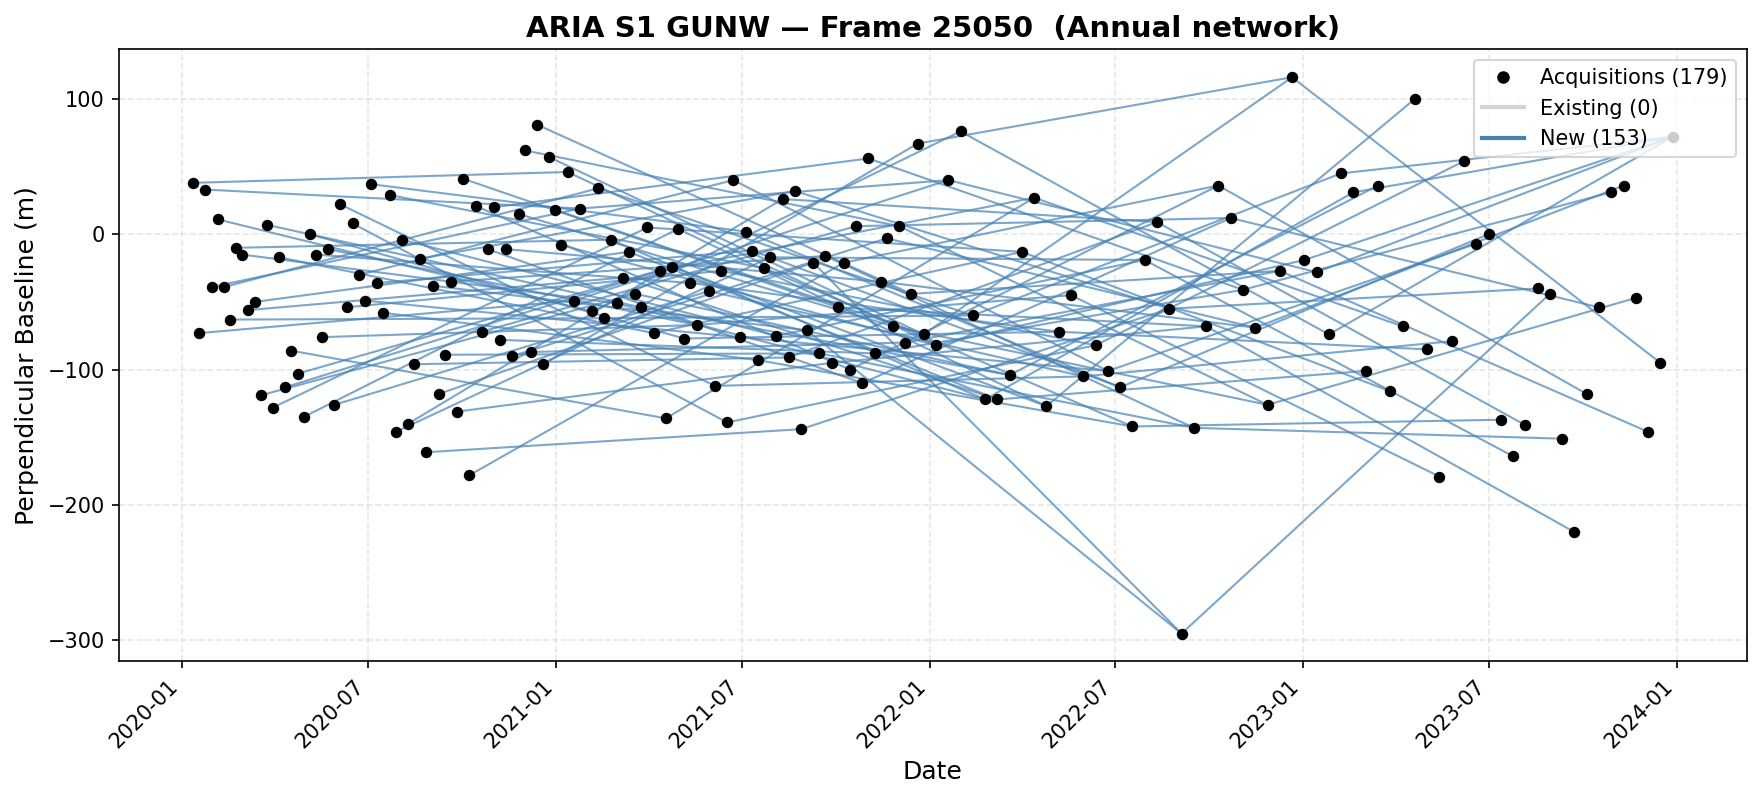

In [25]:
from IPython.display import Image, display
display(Image(filename='support_docs/aria_baseline_frame25050_1.png'))

<div class="alert alert-info">
<b>Tip:</b> 
You can build combined networks (e.g., sequential + annual) by running each network type into its own work directory using <code>-w</code>:

<pre>
ariaOrderASF.py --getpairs --frame 25050 --num-neighbors 1 -s 20220101 -e 20230601 -w ./seq
ariaOrderASF.py --getpairs --frame 25050 --network annual -s 20220101 -e 20230601 -w ./annual
</pre>
</div>

<a id='step3'></a>

## Step 3: Order pairs (`--orderpairs`)

Once the pairs CSV has been generated (and optionally edited to remove unwanted pairs), you can submit the new pairs for processing via HyP3.

The ordering step requires:
- **`--frame`**: The ARIA frame ID
- **`--pairs-file`**: Path to the pairs CSV generated by `--getpairs`

### Dry run (preview without ordering)

**Always start with a `--dry-run`** to preview what will be submitted and the associated credit cost, without actually placing an order or spending credits:

In [20]:
!ariaOrderASF.py --orderpairs --frame 25050 --pairs-file aria_pairs_frame25050.csv --dry-run

2026-03-30 15:16:23,077 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:16:23,077 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:16:23,077 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:16:23,077 - ariaOrderASF.py - INFO - ======================================================================

  ARIA S1 GUNW Order Summary — Frame 25050
  Pairs file     : aria_pairs_frame25050.csv
  Total new pairs: 4
  Submitting     : 4 pair(s)
  Job name       : ARIA_frame25050_20260330_131623
  Credit cost    : 240  (4 x 60)
  Credits avail. : 20
  After submit   : -220 credits remaining

  #    Reference (earlier)    Secondary (later)     
  ---- ---------------------- ----------------------
  1    2026-03-05             2026-03-17            
  2    2026-03-11             2026-03-17            
  3    2026-03-11             2026-03-23            
  

The dry run output shows:
- The total number of new pairs to submit
- A table listing each pair (reference and secondary dates)
- The job name that will be used for tracking
- The credit cost and your remaining credits

### Submit with a limit (safety cap)

If you have more pairs than your remaining credits allow, or you want to test with a small batch first, use **`--limit`** to cap the number of pairs submitted:

In [21]:
!ariaOrderASF.py --orderpairs --frame 25050 --pairs-file aria_pairs_frame25050.csv --limit 2 --dry-run

2026-03-30 15:16:39,472 - ariaOrderASF.py - INFO - ======================================================================
2026-03-30 15:16:39,472 - ariaOrderASF.py - INFO - ARIA Sentinel-1 GUNW Frame Query / Order Tool
2026-03-30 15:16:39,472 - ariaOrderASF.py - INFO - NOTE: This tool supports Sentinel-1 only, not NISAR.
2026-03-30 15:16:39,472 - ariaOrderASF.py - INFO - ======================================================================

  ARIA S1 GUNW Order Summary — Frame 25050
  Pairs file     : aria_pairs_frame25050.csv
  Total new pairs: 4
  Limit applied  : 2
  Submitting     : 2 pair(s)
  Job name       : ARIA_frame25050_20260330_131639
  Credit cost    : 120  (2 x 60)
  Credits avail. : 20
  After submit   : -100 credits remaining

  #    Reference (earlier)    Secondary (later)     
  ---- ---------------------- ----------------------
  1    2026-03-05             2026-03-17            
  2    2026-03-11             2026-03-17            

  ** DRY RUN — no jobs submitted,

### Submit the order

When you are satisfied with the preview, remove **`--dry-run`** to submit the jobs. The tool will display a summary and the estimated credit cost before submitting.

<div class="alert alert-danger">
<b>Caution:</b> 
Removing <code>--dry-run</code> will submit processing jobs and <b>consume credits</b> from your ASF monthly quota. Make sure you have reviewed the dry-run output before proceeding.
</div>

In [ ]:
# Uncomment the line below to actually submit the order
# !ariaOrderASF.py --orderpairs --frame 25050 --pairs-file aria_pairs_frame25050.csv --limit 2

<div class="alert alert-info">
<b>Tip:</b> 
You can provide a custom job name using <code>--job-name</code> for easier tracking. If not provided, an auto-generated name will be used in the format: <code>ARIA_frame{ID}_{YYYYMMDD_HHMMSS}</code>.
</div>

### Editing the pairs CSV before ordering

The pairs CSV file generated by `--getpairs` can be manually edited before ordering. This allows you to:
- Remove specific pairs you do not need
- Focus on a particular time period
- Prioritize certain pairs

The CSV contains columns for reference date, secondary date, temporal baseline, perpendicular baseline, and whether the pair already exists at ASF. Only pairs marked as new will be submitted for ordering.

<a id='step4'></a>

## Step 4: Check job status (`--statusjobs`)

After submitting an order, you can check the status of your HyP3 processing jobs. You can query by:
- **Job name** using **`--status-name`**: Returns all jobs matching the name assigned during ordering
- **Job IDs** using **`--job-ids`**: Query specific job IDs (comma-separated)

### Query by job name

In [ ]:
# Replace with the job name shown after your submission
# !ariaOrderASF.py --statusjobs --status-name ARIA_frame25050_20260311_120000

### Query by job IDs

In [ ]:
# Replace with actual job IDs from your submission
# !ariaOrderASF.py --statusjobs --job-ids "abc123-def456,ghi789-jkl012"

<div class="alert alert-info">
<b>Tip:</b> 
You can also monitor your jobs directly through the <a href="https://search.asf.alaska.edu/">ASF Vertex</a> web interface under the On Demand section. Once processing is complete, the GUNW products will be available through the regular ASF Vertex search page under ARIA S1 GUNW products.
</div>

## Summary

This notebook demonstrated the full **`ariaOrderASF.py`** workflow:

1. **`--getframes`**: Discovered ARIA frames over the Brussels, Belgium area
2. **`--getpairs`**: Generated sequential nearest-2-neighbor interferogram pairs for frame 25050, identifying which pairs already exist at ASF and which need to be ordered
3. **`--orderpairs`**: Previewed the order with `--dry-run` and demonstrated how to submit with `--limit` for safety
4. **`--statusjobs`**: Showed how to track job status by name or job ID

**Key tips:**
- Always use **`--dry-run`** before submitting to preview the credit cost
- Use **`--limit`** to submit in manageable batches
- Edit the pairs CSV to remove unwanted pairs before ordering
- Use different **`-w`** work directories when combining multiple network types
- Monitor jobs via `--statusjobs` or the ASF Vertex web interface